In [1]:
import pandas as pd
import re
import urllib.request

from Bio.ExPASy.cellosaurus import parse
from common import features_dir
from cytof import get_samples
from pathlib import Path


def download_cellosaurus_file(file_dir: Path, url="https://ftp.expasy.org/databases/cellosaurus/cellosaurus.txt", filename="cellosaurus.txt"):
    """Download the Cellosaurus annotation file if not present in the given directory (file_dir)."""
    file_path = file_dir / filename

    if not file_path.is_file():
        print(f"File '{filename}' not found in {features_dir}. Downloading from {url}...")
        try:
            features_dir.mkdir(parents=True, exist_ok=True)  # Ensure the directory exists
            urllib.request.urlretrieve(url, file_path)
            print("Download complete.")
        except Exception as e:
            print(f"Error downloading file: {e}")
    else:
        print(f"File '{filename}' already exists in {features_dir}. Skipping download.")


def extract_site(comments_list):
    """Extract disease site preceded by 'Derived from site:' until the first occurrence of 'UBERON=' ontology reference or end of string."""
    for comment in comments_list:
        match = re.search(r'Derived from site:\s*(.+?)(?:\s*UBERON=|$)', comment)
        if match:
            return match.group(1).strip().rstrip(";")
    return 'Unknown'


def extract_msi(comments_list):
    """Extract microsatellite instability status from a list of comments or return 'Unknown'."""
    for comment in comments_list:
        match = re.search(r'Microsatellite instability:\s*(.*?)(?:\s*\||$)', comment)
        if match:
            status_match = re.search(r'(Stable \(MSS\)|Instable \(MSI-low\)|Instable \(MSI-high\))', match.group(1))
            if status_match:
                return status_match.group(0)
    return 'Unknown'


def process_cell_lines(cell_line_dict):
    """Process each cell line's comments to extract site and MSI status."""
    new_dict = {cell_line: {} for cell_line in cell_line_dict.keys()}
    for cell_line, info in cell_line_dict.items():
        comments = info.get('Comments', '')
        info['Site'] = extract_site(comments)
        info['MSI_Status'] = extract_msi(comments)
        new_dict[cell_line] = {"ID": info["ID"], "Site": info["Site"], "MS_Status": info["MSI_Status"], "Disease": info["Disease"]}
    return new_dict


def get_cell_line_cellosaurus_annotations(file_dir: Path):
    # Download annotations
    download_cellosaurus_file(file_dir / "EGFR_MAPK/dream_cytof")
    cellosaurus_filepath = file_dir / "EGFR_MAPK/dream_cytof/cellosaurus.txt"
    cell_lines = [cell_line.lstrip("c") for cell_line in get_samples("dream_cytof")]
    brca_records = {}
    with open(cellosaurus_filepath) as handle:  # https://ftp.expasy.org/databases/cellosaurus/cellosaurus.txt
        records = parse(handle)
        for record in records:
            if record["ID"].replace("-", "").upper() in cell_lines:
                brca_records["c" + record["ID"].replace("-", "").upper()] = {"ID": record["AC"], "Comments": record["CC"], "Disease": record["DI"][0].split(";")[2].lstrip(" ") if record["DI"] else "Unknown"}
            elif record["ID"] == "600MPE":  # cMPE600 is recorded as 600MPE as main ID on cellosaurus
                brca_records["cMPE600"] = {"ID": record["AC"], "Comments": record["CC"], "Disease": record["DI"], "Disease": record["DI"][0].split(";")[2].lstrip(" ") if record["DI"] else "Unknown"}
            elif record["ID"] == "Hs 578T":  # cHs578T is recorded as Hs 578T as main ID on cellosaurus
                brca_records["cHs578T"] = {"ID": record["AC"], "Comments": record["CC"], "Disease": record["DI"], "Disease": record["DI"][0].split(";")[2].lstrip(" ") if record["DI"] else "Unknown"}
    if len(brca_records.keys()) != len(cell_lines):
        print(f"Warning: Number of cell lines in Cellosaurus annotations ({len(brca_records.keys())}) does not match the number of cell lines in the DREAM challenge ({len(cell_lines)}).")

    # Process annotations re. MS status and site and return dataframe
    annotation_df = pd.DataFrame(process_cell_lines(brca_records)).T
    annotation_df.index.name = "cell_line"
    return annotation_df

In [2]:
brca_df = get_cell_line_cellosaurus_annotations(file_dir=features_dir)

File 'cellosaurus.txt' already exists in /Users/fabring/Desktop/DeepMechanisticModels/features_test_new_model. Skipping download.


In [3]:
brca_df

,ID,Site,MS_Status,Disease
cell_line,,,,
c184A1,CVCL_3040,"In situ; Breast, epithelium",Stable (MSS),Unknown
c184B5,CVCL_4688,"In situ; Breast, epithelium",Unknown,Unknown
cMPE600,CVCL_9875,Metastatic; Pleural effusion,Unknown,Invasive breast carcinoma of no special type
cBT20,CVCL_0178,In situ; Breast,Stable (MSS),Invasive breast carcinoma of no special type
cBT474,CVCL_0179,In situ; Breast,Stable (MSS),Invasive breast carcinoma of no special type
cBT483,CVCL_2319,In situ; Breast,Stable (MSS),Invasive breast carcinoma of no special type
cBT549,CVCL_1092,In situ; Breast,Stable (MSS),Invasive breast carcinoma of no special type
cCAL148,CVCL_1106,Metastatic; Pleural effusion,Stable (MSS),Breast carcinoma
cCAL51,CVCL_1110,Metastatic; Pleural effusion,Instable (MSI-low),Breast carcinoma


In [4]:
brca_df["Site"].unique()

array(['In situ; Breast, epithelium', 'Metastatic; Pleural effusion',
       'In situ; Breast', 'Metastatic; Skin', 'Metastatic; Ascites',
       'Unknown', 'Metastatic; Brain', 'Metastatic; Pericardial effusion',
       'Metastatic; Axillary lymph node'], dtype=object)

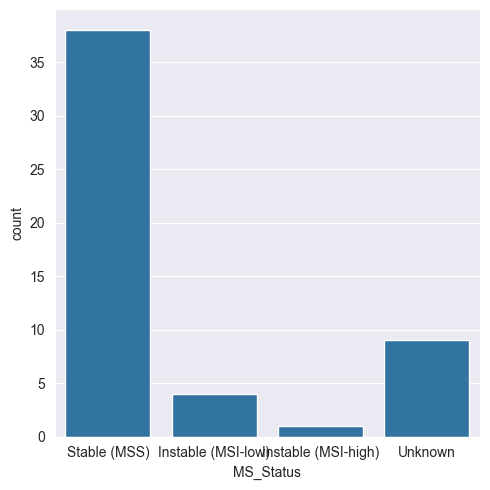

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(data=brca_df, x='MS_Status', kind='count', order=["Stable (MSS)", "Instable (MSI-low)", "Instable (MSI-high)", "Unknown"])

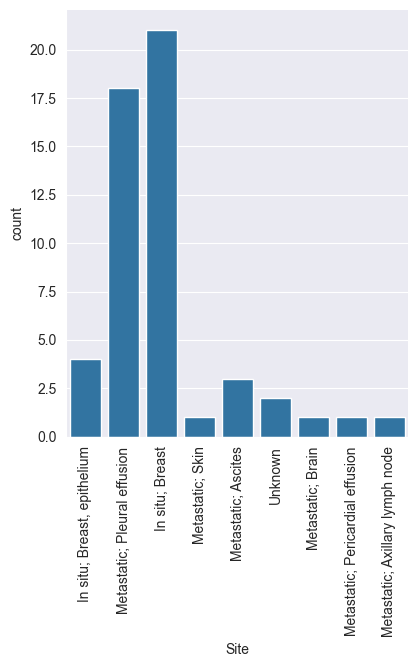

In [6]:
sns.catplot(data=brca_df, x='Site', kind='count')
plt.xticks(rotation=90);

Take a look at Instable cell-lines

In [7]:
brca_df[~brca_df["MS_Status"].isin(["Stable (MSS)", "Unknown"])]

,ID,Site,MS_Status,Disease
cell_line,,,,
cCAL51,CVCL_1110,Metastatic; Pleural effusion,Instable (MSI-low),Breast carcinoma
cHCC1500,CVCL_1254,In situ; Breast,Instable (MSI-low),Breast ductal carcinoma
cHCC1569,CVCL_1255,In situ; Breast,Instable (MSI-high),Breast ductal carcinoma
cOCUBM,CVCL_1621,Metastatic; Pleural effusion,Instable (MSI-low),Breast carcinoma
cZR7530,CVCL_1661,Metastatic; Ascites,Instable (MSI-low),Invasive breast carcinoma of no special type


Take a look at cell-lines for which we lack any kind of info/annotation

In [8]:
brca_df[(brca_df["MS_Status"] == "Unknown") | (brca_df["Site"] == "Unknown")]

,ID,Site,MS_Status,Disease
cell_line,,,,
c184B5,CVCL_4688,"In situ; Breast, epithelium",Unknown,Unknown
cMPE600,CVCL_9875,Metastatic; Pleural effusion,Unknown,Invasive breast carcinoma of no special type
cHBL100,CVCL_4362,Unknown,Stable (MSS),Unknown
cHCC2185,CVCL_3375,Metastatic; Pleural effusion,Unknown,Metastatic breast lobular carcinoma
cHCC3153,CVCL_3377,Unknown,Unknown,Breast ductal carcinoma
cMCF12A,CVCL_3744,"In situ; Breast, epithelium",Unknown,Unknown
cMDAMB134VI,CVCL_0617,Metastatic; Pleural effusion,Unknown,Invasive breast lobular carcinoma
cMX1,CVCL_4774,In situ; Breast,Unknown,Breast carcinoma
cUACC3199,CVCL_4042,Metastatic; Axillary lymph node,Unknown,Invasive breast carcinoma of no special type


In [9]:
brca_df["MS_Status"].value_counts()

MS_Status
Stable (MSS)           38
Unknown                 9
Instable (MSI-low)      4
Instable (MSI-high)     1
Name: count, dtype: int64

In [10]:
brca_df["Site"].value_counts()

Site
In situ; Breast                     21
Metastatic; Pleural effusion        18
In situ; Breast, epithelium          4
Metastatic; Ascites                  3
Unknown                              2
Metastatic; Skin                     1
Metastatic; Brain                    1
Metastatic; Pericardial effusion     1
Metastatic; Axillary lymph node      1
Name: count, dtype: int64

## `cbioportal` annotations

In [11]:
from cbio_py import cbio_mod as cb

In [12]:
cell_lines = [cell_line.lstrip("c") for cell_line in get_samples("dream_cytof")]
cbioportal_names = [cl + '_BREAST' for cl in cell_lines]

In [13]:
all_muts = cb.getMutationsInMolecularProfile(
    "ccle_broad_2019",
    "ccle_broad_2019",
    return_type="dict"
)

In [14]:
brca_muts = [mut for mut in all_muts if "BREAST" in mut["sampleId"]]

In [15]:
cell_lines_ccle_names = [cell_line.upper() +"_BREAST" for cell_line in cell_lines]

In [16]:
brca_mut_df = pd.DataFrame(brca_muts)
brca_mut_df["sampleId"] = brca_mut_df["sampleId"].apply(lambda x: x.split("_")[0])
brca_mut_df.to_csv(features_dir / "EGFR_MAPK/dream_cytof/cbioportal_ccle_broad2019_mutations_breast.csv")
brca_mut_df["gene"] = brca_mut_df["gene"].apply(lambda x: x["hugoGeneSymbol"])
brca_mut_df = brca_mut_df[
    ["chr", "entrezGeneId", "gene", "keyword", "mutationType", "sampleId", "proteinChange", "variantType"]
]
brca_mut_df.to_csv(features_dir / "EGFR_MAPK/dream_cytof/cbioportal_ccle_broad2019_mutations_breast_processed.csv")
brca_mut_df = brca_mut_df[brca_mut_df["sampleId"].isin([cell_line.upper() for cell_line in cell_lines])]

### We are missing mutation info for 10 cell-lines, of which 1 validation cell-lines (HCC-2185)
Checked by manually subsetting to `BREAST` on https://www.cbioportal.org/study/clinicalData?id=ccle_broad_2019

In [17]:
brca_mut_df = pd.read_csv(
    features_dir / "EGFR_MAPK/dream_cytof/cbioportal_ccle_broad2019_mutations_breast_processed.csv"
)
brca_mut_df = brca_mut_df[brca_mut_df["sampleId"].isin([cell_line.upper() for cell_line in cell_lines])]
sorted([sample for sample in cell_lines if sample.upper() not in brca_mut_df.sampleId.unique()])

['184A1',
 '184B5',
 'HBL100',
 'HCC2185',
 'HCC3153',
 'MCF10A',
 'MCF12A',
 'MPE600',
 'MX1',
 'UACC3199']

We can count the frequency/occurrence of unique mutations (gene / mutationType / variantType)

In [18]:
brca_mut_df.groupby(["gene", "mutationType", "variantType"])["sampleId"].count().sort_values(ascending=False)

gene     mutationType       variantType
TTN      Missense_Mutation  SNP            82
MUC16    Missense_Mutation  SNP            38
MUC4     Missense_Mutation  SNP            24
FLG      Missense_Mutation  SNP            22
TP53     Missense_Mutation  SNP            21
                                           ..
IL22RA2  Nonsense_Mutation  SNP             1
IL24     Missense_Mutation  SNP             1
IL27RA   Missense_Mutation  DNP             1
                            SNP             1
ZZEF1    Missense_Mutation  SNP             1
Name: sampleId, Length: 11885, dtype: int64

Or the occurrence of mutations in a particular gene altogether

In [19]:
brca_mut_df.groupby(["gene"])["sampleId"].count().sort_values(ascending=False)

gene
TTN       86
MUC16     45
TP53      33
MUC4      28
FLG       26
          ..
KLF14      1
KLC4       1
KLC2       1
KISS1R     1
ZZEF1      1
Name: sampleId, Length: 9920, dtype: int64

In [20]:
gene_hit_count = brca_mut_df.groupby(["gene"])["sampleId"].count().sort_values(ascending=False)
gene_hit_count = gene_hit_count[gene_hit_count >= 4]
gene_list = gene_hit_count.index.tolist()

In [21]:
ion_channel_genes = {
    ion: [gene for gene in gene_list if gene.startswith(pattern)]
    for ion, pattern in zip(
        ["sodium", "potassium", "potassium_2pore", "calcium", "chloride", "transient receptor potential", "hydrogen voltage gated channel"],
        ["SCN", "KCN", "KCNK", "CACN", "CLCN", "TRP", "HVCN"]
    )
}
ion_channel_genes

{'sodium': ['SCN3A', 'SCN11A', 'SCN8A', 'SCN2A'],
 'potassium': ['KCNQ3', 'KCNQ4', 'KCNH3'],
 'potassium_2pore': [],
 'calcium': ['CACNA2D3',
  'CACNA1H',
  'CACNA1F',
  'CACNA1E',
  'CACNA1C',
  'CACNA1A',
  'CACNA1S'],
 'chloride': ['CLCN3', 'CLCN1'],
 'transient receptor potential': ['TRPV4', 'TRPC5', 'TRPM7', 'TRPM1'],
 'hydrogen voltage gated channel': []}

In [22]:
ion_channel_gene_list = [x for xs in ion_channel_genes.values() for x in xs]

In [23]:
signature_6ich = ["CACNA1C", "CACNA2D2", "CACNB2", "KCNJ11", "SCN3A", "SCN3B"]
[gene for gene in ion_channel_gene_list if gene in signature_6ich]

['SCN3A', 'CACNA1C']

In [24]:
brca_mut_df["gene"].value_counts().sort_values(ascending=False)

gene
TTN       86
MUC16     45
TP53      33
MUC4      28
FLG       26
          ..
KCNJ2      1
NDOR1      1
NUP160     1
SMAP1      1
PGRMC1     1
Name: count, Length: 9920, dtype: int64

In [25]:
brca_mut_df[brca_mut_df.gene.isin(ion_channel_gene_list)].groupby(["sampleId"])["gene"].apply(lambda x: list(x))

sampleId
BT20                                                   [CACNA1E]
BT474                                                  [CACNA1A]
BT483                  [KCNH3, SCN8A, CACNA1H, CACNA1F, CACNA1F]
CAL148                                        [SCN11A, CACNA2D3]
CAL51                            [SCN11A, TRPV4, CACNA1C, KCNH3]
CAL851                                                   [KCNQ3]
DU4475                                         [CACNA2D3, TRPC5]
EFM192A                                                  [KCNQ3]
EVSAT                                    [KCNQ4, CACNA1S, SCN3A]
HCC1187                                           [KCNH3, SCN3A]
HCC1395                                           [TRPM7, KCNQ3]
HCC1419                                                  [TRPV4]
HCC1428                                                [CACNA1F]
HCC1500                                                  [TRPM7]
HCC1569        [SCN3A, CACNA1S, KCNQ4, CACNA1E, CACNA1S, SCN1...
HCC1937         

In [26]:
brca_mut_df.groupby("sampleId")[["gene", "variantType"]].count()

,gene,variantType
sampleId,,
BT20,414,414
BT474,1019,1019
BT483,538,538
BT549,199,199
CAL148,577,577
CAL51,822,822
CAL851,216,216
DU4475,257,257
EFM192A,190,190


In [27]:
brca_mut_df.groupby("sampleId")[["gene"]].nunique()

,gene
sampleId,
BT20,389
BT474,932
BT483,501
BT549,195
CAL148,549
CAL51,779
CAL851,210
DU4475,253
EFM192A,189


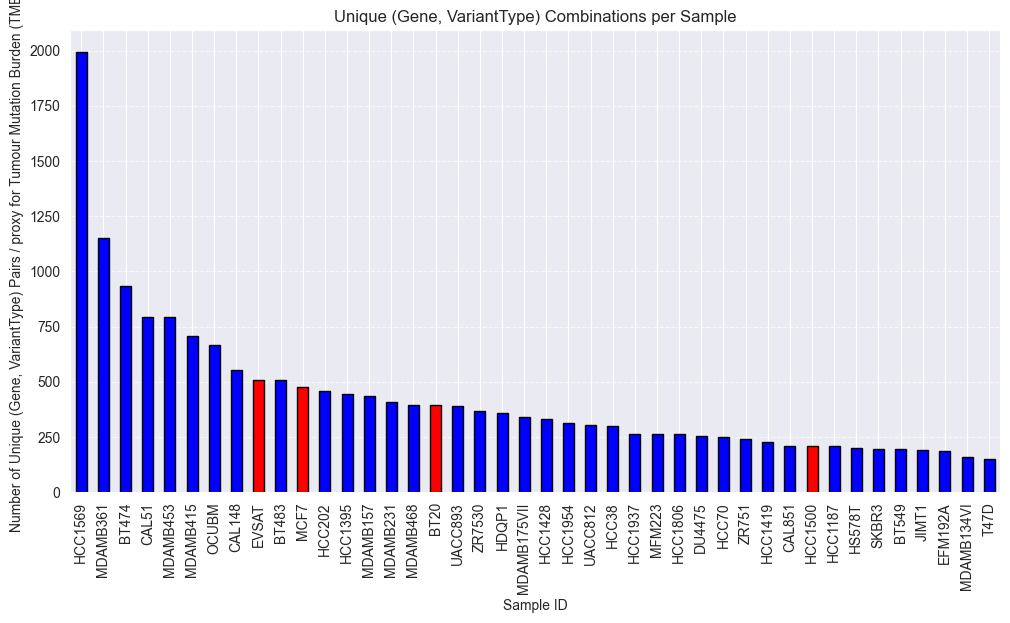

In [28]:
# Assuming brca_mut_df is already loaded
# Compute the number of unique (gene, variantType) pairs per sampleId
unique_combinations = brca_mut_df.groupby("sampleId")[["gene", "variantType"]].apply(lambda x: x.drop_duplicates().shape[0])

# Plot the results
plt.figure(figsize=(12, 6))
unique_combinations.sort_values(ascending=False, inplace=True)
# Define special colors for specific cell lines
highlight_samples = {"BT20": "red", "MCF7": "red", "HCC1500": "red", "EVSAT": "red"}
colors = [highlight_samples.get(sample, "blue") for sample in unique_combinations.index]
unique_combinations.plot(kind='bar', color=colors, edgecolor='black')

plt.xlabel("Sample ID")
plt.ylabel("Number of Unique (Gene, VariantType) Pairs / proxy for Tumour Mutation Burden (TMB)")
plt.title("Unique (Gene, VariantType) Combinations per Sample")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


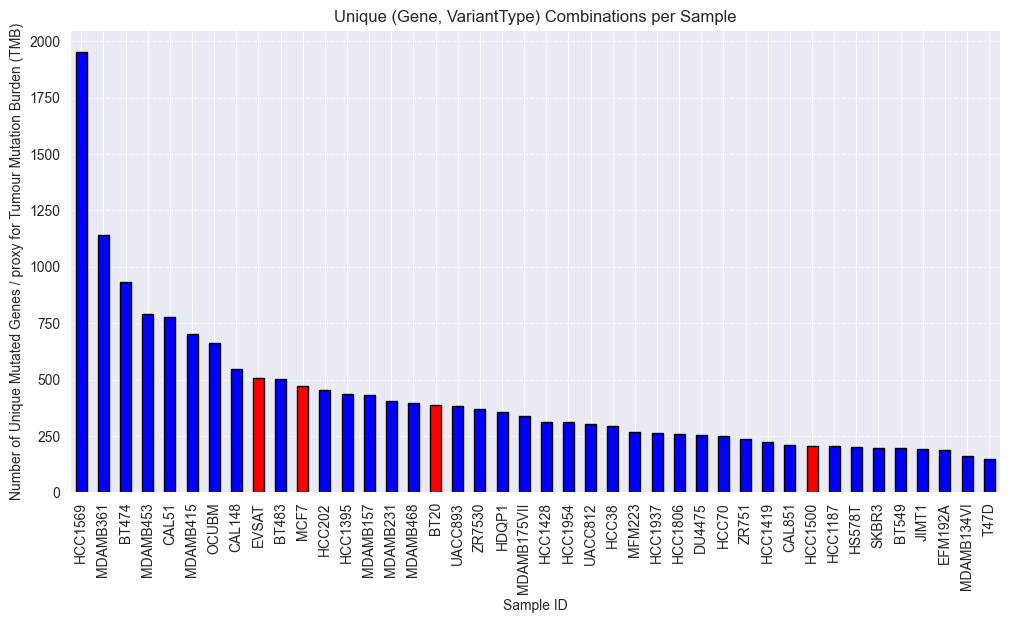

In [29]:
# Assuming brca_mut_df is already loaded
# Compute the number of unique mutated genes per sampleId
unique_combinations = brca_mut_df.groupby("sampleId")[["gene"]].apply(lambda x: x.drop_duplicates().shape[0])

# Plot the results
plt.figure(figsize=(12, 6))
unique_combinations.sort_values(ascending=False, inplace=True)
# Define special colors for specific cell lines
highlight_samples = {"BT20": "red", "MCF7": "red", "HCC1500": "red", "EVSAT": "red"}
colors = [highlight_samples.get(sample, "blue") for sample in unique_combinations.index]
unique_combinations.plot(kind='bar', color=colors, edgecolor='black')

plt.xlabel("Sample ID")
plt.ylabel("Number of Unique Mutated Genes / proxy for Tumour Mutation Burden (TMB)")
plt.title("Unique (Gene, VariantType) Combinations per Sample")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


In [30]:
from gprofiler import GProfiler

# Initialize g:Profiler
gp = GProfiler(return_dataframe=True)

# Query GO enrichment
go_results = gp.profile(organism="hsapiens", query=gene_list, sources=["GO:BP", "GO:MF", "GO:CC"])

go_results[go_results.source == "GO:BP"].sort_values(by="term_size", ascending=False)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
80,GO:BP,GO:0065007,biological regulation,8.283990e-09,True,"""Any process that modulates a measurable attri...",12671,876,624,21017,0.712329,0.049246,query_1,[GO:0008150]
92,GO:BP,GO:0050789,regulation of biological process,3.048924e-08,True,"""Any process that modulates the frequency, rat...",12278,876,606,21017,0.691781,0.049357,query_1,"[GO:0008150, GO:0065007]"
93,GO:BP,GO:0050794,regulation of cellular process,3.139784e-08,True,"""Any process that modulates the frequency, rat...",11876,876,590,21017,0.673516,0.049680,query_1,"[GO:0009987, GO:0050789]"
7,GO:BP,GO:0071840,cellular component organization or biogenesis,6.201447e-24,True,"""A process that results in the biosynthesis of...",8323,876,502,21017,0.573059,0.060315,query_1,[GO:0009987]
6,GO:BP,GO:0016043,cellular component organization,4.892149e-24,True,"""A process that results in the assembly, arran...",8108,876,493,21017,0.562785,0.060804,query_1,[GO:0071840]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,GO:BP,GO:1902656,calcium ion import into cytosol,9.421436e-05,True,"""The directed movement of calcium ion into a c...",47,876,13,21017,0.014840,0.276596,query_1,[GO:0006816]
237,GO:BP,GO:0098703,calcium ion import across plasma membrane,6.381309e-04,True,"""The directed movement of calcium ions from ou...",46,876,12,21017,0.013699,0.260870,query_1,"[GO:0070509, GO:0097553, GO:0098659, GO:1902656]"
386,GO:BP,GO:0031112,positive regulation of microtubule polymerizat...,2.958711e-02,True,"""Any process that activates or increases the f...",36,876,9,21017,0.010274,0.250000,query_1,"[GO:0031109, GO:0031110, GO:0051495]"
351,GO:BP,GO:0000212,meiotic spindle organization,1.648581e-02,True,"""A process that is carried out at the cellular...",19,876,7,21017,0.007991,0.368421,query_1,"[GO:0007051, GO:1903046]"


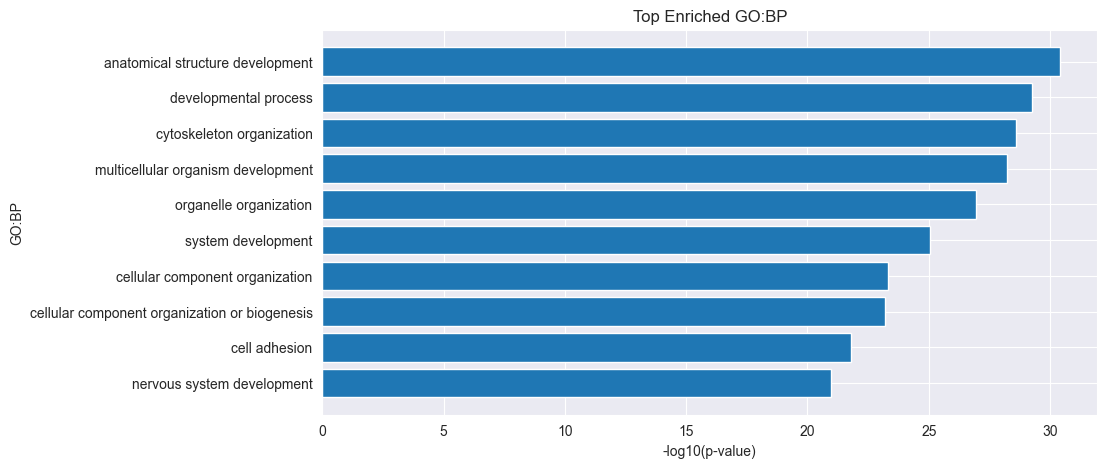

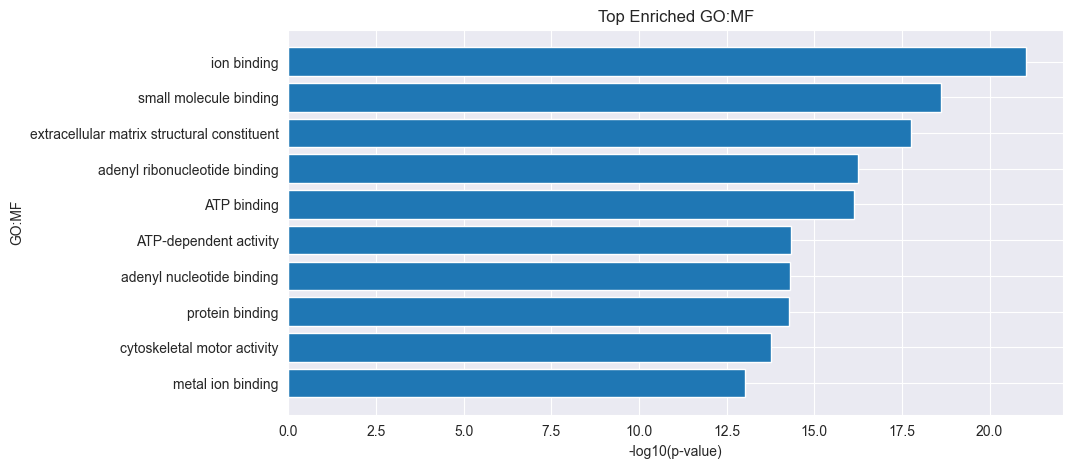

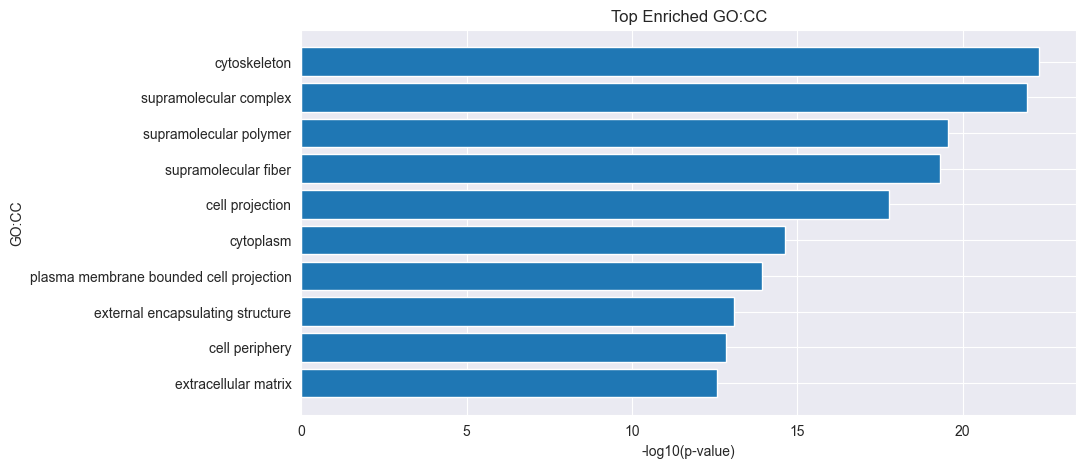

In [31]:
import matplotlib.pyplot as plt
import numpy as np

significant_go = go_results[go_results["p_value"] < 0.05]

for source in ["GO:BP", "GO:MF", "GO:CC"]:
    # Select top enriched GO terms (Biological Process)
    top_go = significant_go[significant_go["source"] == source].sort_values("p_value").head(10)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.barh(top_go["name"], -np.log10(top_go["p_value"]))
    plt.xlabel("-log10(p-value)")
    plt.ylabel(f"{source}")
    plt.title(f"Top Enriched {source}")
    plt.gca().invert_yaxis()
    plt.show()

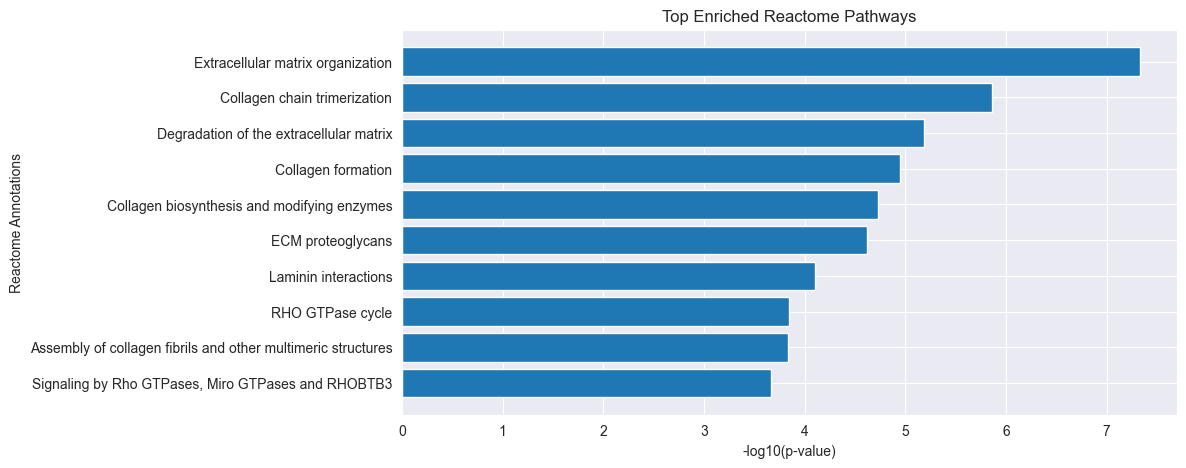

In [32]:
# Query g:Profiler for pathway enrichment
gp = GProfiler(return_dataframe=True)
reactome_results = gp.profile(organism="hsapiens", query=gene_list, sources=["REAC"])

significant_reactome = reactome_results[reactome_results["p_value"] < 0.05]
# Select top enriched GO terms (Biological Process)
top_reac = significant_reactome.sort_values("p_value").head(10)

# Plot
plt.figure(figsize=(10, 5))
plt.barh(top_reac["name"], -np.log10(top_reac["p_value"]))
plt.xlabel("-log10(p-value)")
plt.ylabel("Reactome Annotations")
plt.title("Top Enriched Reactome Pathways")
plt.gca().invert_yaxis()
plt.show()

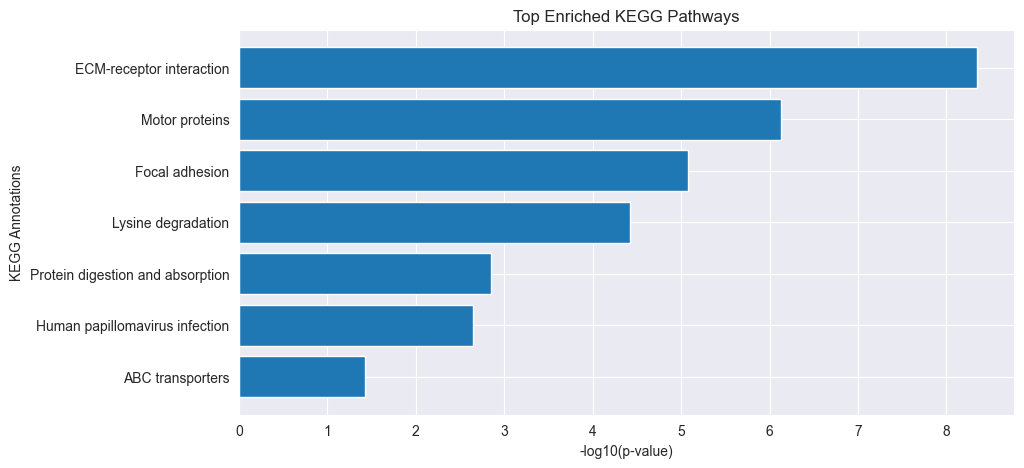

In [33]:
# Query g:Profiler for pathway enrichment
gp = GProfiler(return_dataframe=True)
kegg_results = gp.profile(organism="hsapiens", query=gene_list, sources=["KEGG"])

significant_kegg = kegg_results[kegg_results["p_value"] < 0.05]
# Select top enriched GO terms (Biological Process)
top_kegg = significant_kegg.sort_values("p_value").head(20)

# Plot
plt.figure(figsize=(10, 5))
plt.barh(top_kegg["name"], -np.log10(top_kegg["p_value"]))
plt.xlabel("-log10(p-value)")
plt.ylabel("KEGG Annotations")
plt.title("Top Enriched KEGG Pathways")
plt.gca().invert_yaxis()
plt.show()

In [34]:
from common import hardest_cell_lines
hardest_cell_lines_ids = [cl[1:] for cl in hardest_cell_lines]
brca_mut_val = brca_mut_df[brca_mut_df.sampleId.isin(hardest_cell_lines_ids)]
brca_mut_val

,Unnamed: 0,chr,entrezGeneId,gene,keyword,mutationType,sampleId,proteinChange,variantType
4413,4413,3,5290,PIK3CA,PIK3CA H1047 missense,Missense_Mutation,BT20,H1047R,SNP
4414,4414,3,5290,PIK3CA,PIK3CA P539 missense,Missense_Mutation,BT20,P539R,SNP
4415,4415,19,5424,POLD1,POLD1 truncating,Nonsense_Mutation,BT20,Q636*,SNP
4416,4416,2,9839,ZEB2,ZEB2 E1094 missense,Missense_Mutation,BT20,E1094K,SNP
4417,4417,20,140689,CBLN4,CBLN4 E85 missense,Missense_Mutation,BT20,E85K,SNP
...,...,...,...,...,...,...,...,...,...
18065,18065,19,199704,ZNF585A,ZNF585A truncating,Frame_Shift_Ins,HCC1500,D674Afs*6,INS
18066,18066,19,199704,ZNF585A,ZNF585A truncating,Frame_Shift_Del,HCC1500,T673Rfs*7,DEL
18067,18067,1,100132406,NBPF10,NaN,In_Frame_Ins,HCC1500,R2726dup,INS
18068,18068,2,653269,POTEI,POTEI truncating,Frame_Shift_Del,HCC1500,S337Dfs*15,DEL


In [35]:
brca_mut_val.groupby(["keyword", "variantType"])[["sampleId"]].count().sort_values(by="sampleId", ascending=False)

,,sampleId
keyword,variantType,
MALRD1 A114 missense,SNP,2
MAGEA2B M247 missense,SNP,2
PKD2L1 G291 missense,SNP,2
PTPRD truncating,SNP,2
MMP17 G36 missense,SNP,2
...,...,...
FMO3 T121 missense,SNP,1
FLT3 C368 missense,DNP,1
FLNC G54 missense,SNP,1


In [36]:
mutcount_df = brca_mut_df.dropna(subset=["keyword"]).groupby(["keyword", "variantType"])["sampleId"].count().reset_index().rename(columns={"sampleId": "mutCount"}).sort_values(by="mutCount", ascending=False)

In [37]:
mutcount_df

,keyword,variantType,mutCount
3101,CLDN8 truncating,INS,8
11584,PIK3CA H1047 missense,SNP,8
7987,KRT85 L403 missense,SNP,7
7948,KRT16 truncating,DEL,6
6360,GRAMD2A truncating,INS,6
...,...,...,...
6127,GLI1 L478 missense,SNP,1
6128,GLI2 K485 missense,SNP,1
6129,GLI2 M1222 missense,SNP,1
6130,GLI3 R905 missense,SNP,1


In [38]:
mutcount_df[mutcount_df.mutCount >= 4]

,keyword,variantType,mutCount
3101,CLDN8 truncating,INS,8
11584,PIK3CA H1047 missense,SNP,8
7987,KRT85 L403 missense,SNP,7
7948,KRT16 truncating,DEL,6
6360,GRAMD2A truncating,INS,6
16373,TTC3 truncating,INS,5
15992,TP53 truncating,SNP,5
8537,LTN1 truncating,INS,5
12445,PTEN truncating,DEL,5
13785,SF3B1 truncating,INS,4


In [39]:
brca_mut_df[(brca_mut_df["keyword"] == "TP53 truncating") & (brca_mut_df.sampleId == "HCC1569_BREAST")]

,Unnamed: 0,chr,entrezGeneId,gene,keyword,mutationType,sampleId,proteinChange,variantType


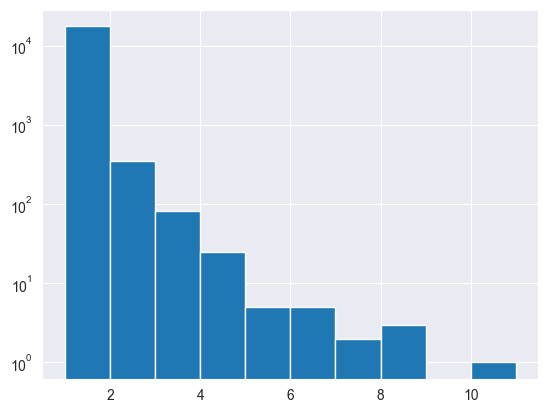

In [40]:
plt.hist(brca_mut_df.groupby("keyword")["sampleId"].count().reset_index()["sampleId"].values)
plt.yscale("log")
plt.show()

In [41]:
brca_mut_df.groupby("keyword")["sampleId"].count().reset_index()["sampleId"].values

array([1, 1, 1, ..., 1, 1, 1])

In [42]:
brca_filtered = brca_mut_df.dropna(subset=["keyword"])
brca_filtered = brca_filtered[brca_filtered["keyword"].str.contains("EGFR")]
brca_filtered

,Unnamed: 0,chr,entrezGeneId,gene,keyword,mutationType,sampleId,proteinChange,variantType
668,668,7,1956,EGFR,EGFR R309 missense,Missense_Mutation,HCC38,R309G,SNP
5065,5065,7,1956,EGFR,EGFR T678 missense,Missense_Mutation,MDAMB361,T678M,SNP
12163,12163,7,1956,EGFR,EGFR E711 missense,Missense_Mutation,EVSAT,E711K,SNP
